# 02. Modeling — Batch 1 학습 → Batch 2 평가

EDA 에서 세운 모델 설계 전략(`01_EDA.ipynb` 6절)으로 먼저 모델을 만들고(1차), 결과의 원인을 분석해 근거를 바탕으로 수정한 뒤(2차), 원논문 Target(MAPE 9.1%)과 비교한다.

**데이터 분할**
```
Batch 1 (36셀, 정책 20개)
├── 학습 구간 28셀 (정책 16개) → Train CV : GroupKFold(5, group = 정책) 평균 MAPE
└── Hold-out 8셀 (정책 4개)   → Valid    : 학습 구간 전체로 학습한 모델의 MAPE
Batch 1 전체로 재학습          → Test     : Batch 2 (39셀) MAPE
```

- Target : `log10(cycle_life)` 로 학습 → 예측값을 10^x 로 되돌려 MAPE 계산
- Hold-out 정책 : 평균 수명 순으로 정렬한 정책 20개 중 4개를 균등 간격으로 선택 → Valid 가 수명 범위를 고르게 포함
- CV / Hold-out 모두 **충전 정책 단위**로 나눈다 → 같은 정책 셀이 학습과 검증에 나뉘어 들어가는 누수 방지
- 모델 선택은 **Valid (Batch 1 Hold-out) MAPE** 로 한다. Test 는 마지막 성능 확인에만 쓰고 모델을 고르는 데 쓰지 않는다 → Test 로 모델을 고르면 Test 점수가 "처음 보는 배치에서의 성능" 을 나타내지 못하기 때문
- Gap 은 "뒤 단계 MAPE − 앞 단계 MAPE" 로 계산 → (+) 면 성능 저하

학습 · 평가 코드는 `src/train.py` 에 있다.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.train import (FEATURE_SETS, MODELS, PLAN_SETS, ROBUST_SETS, LINEAR_MODELS, TARGET_MAPE,
                       load_dataset, holdout_policies, split_batch1, compare_all, select_by_valid,
                       covariate_shift, report_table, mape)
from src.viz import set_style, BATCH_COLORS, MUTED, TEXT, GRID

set_style()
pd.set_option("display.precision", 2)
FIG_DIR = Path("../results/figures")
RESULTS_DIR = Path("../results")


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")


def short(fs):
    return fs.split(" ")[0]

---
## 1. 데이터 준비

In [2]:
b1, b2 = load_dataset()
valid_policies = holdout_policies(b1)
train, valid = split_batch1(b1, valid_policies)

pd.DataFrame({
    "셀 수": [len(train), len(valid), len(b2)],
    "정책 수": [train["policy"].nunique(), valid["policy"].nunique(), b2["policy"].nunique()],
    "수명 최소": [train["cycle_life"].min(), valid["cycle_life"].min(), b2["cycle_life"].min()],
    "수명 중앙값": [train["cycle_life"].median(), valid["cycle_life"].median(), b2["cycle_life"].median()],
    "수명 최대": [train["cycle_life"].max(), valid["cycle_life"].max(), b2["cycle_life"].max()],
}, index=["Train (Batch 1 학습 구간)", "Valid (Batch 1 Hold-out)", "Test (Batch 2)"]).astype(int)

,셀 수,정책 수,수명 최소,수명 중앙값,수명 최대
Train (Batch 1 학습 구간),28,16,534,772,1074
Valid (Batch 1 Hold-out),8,4,636,786,1017
Test (Batch 2),39,12,392,472,1186


In [3]:
print("Hold-out 정책 :", valid_policies)
valid[["policy", "cycle_life"]].sort_values("cycle_life")

Hold-out 정책 : ['8C(25%)-3.6C', '4.8C(80%)-4.8C', '5.4C(60%)-3C', '6C(40%)-3C']


,policy,cycle_life
cell_id,,
b1c6,4.8C(80%)-4.8C,636.0
b1c43,8C(25%)-3.6C,651.0
b1c42,8C(25%)-3.6C,702.0
b1c15,5.4C(60%)-3C,719.0
b1c25,6C(40%)-3C,854.0
b1c7,4.8C(80%)-4.8C,870.0
b1c14,5.4C(60%)-3C,880.0
b1c24,6C(40%)-3C,1017.0


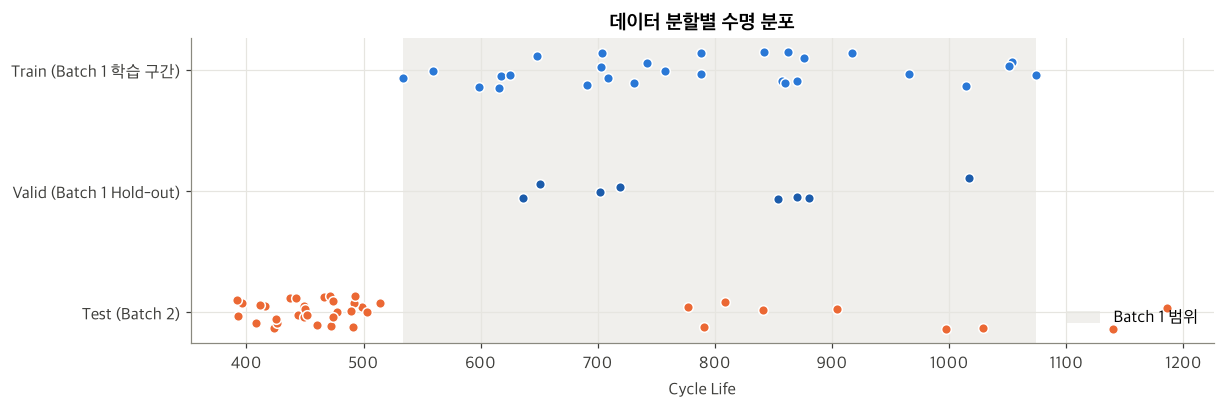

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.6))
rng = np.random.default_rng(0)
groups = [("Train (Batch 1 학습 구간)", train, BATCH_COLORS["b1"]),
          ("Valid (Batch 1 Hold-out)", valid, "#1c5cab"),
          ("Test (Batch 2)", b2, BATCH_COLORS["b2"])]
for i, (name, d, color) in enumerate(groups):
    ax.scatter(d["cycle_life"], i + rng.uniform(-0.15, 0.15, len(d)), s=40, color=color,
               edgecolor="white", lw=1, zorder=3)
ax.axvspan(b1["cycle_life"].min(), b1["cycle_life"].max(), color=GRID, alpha=0.6, lw=0, label="Batch 1 범위")
ax.set_yticks(range(3), [g[0] for g in groups])
ax.invert_yaxis()
ax.set(xlabel="Cycle Life", title="데이터 분할별 수명 분포")
ax.legend(loc="lower right")
savefig(fig, "fig12_data_split")
plt.show()

**[확인]**
- Hold-out 8셀은 636 ~ 1017 로 Batch 1 수명 범위를 고르게 포함한다
- Test(Batch 2) 는 39셀 중 30셀이 Batch 1 범위(534 ~ 1074)보다 짧다 → EDA Q1 에서 예상한 외삽 구간

---
## 2. 1차 모델링 — EDA 기반 설계 전략

EDA 에서 정한 3단계 피처 세트(S1 ~ S3)와 5개 모델을 조합한다. 비교용으로 후보 피처 전체(IR 제외 20개)도 함께 돌린다.
각 조합은 학습 구간 GroupKFold CV 로 하이퍼파라미터를 고른 뒤 Valid 를 평가한다.

| 피처 세트 | 피처 |
|---|---|
| S1 | `dq_var` |
| S2 | S1 + `dq_lowv_mean` |
| S3 | S2 + `qd_2`, `fade_slope_91_100` |
| ALL (비교용) | 후보 피처 23개 중 IR 3개를 뺀 20개 (Batch 2 IR 결측) |

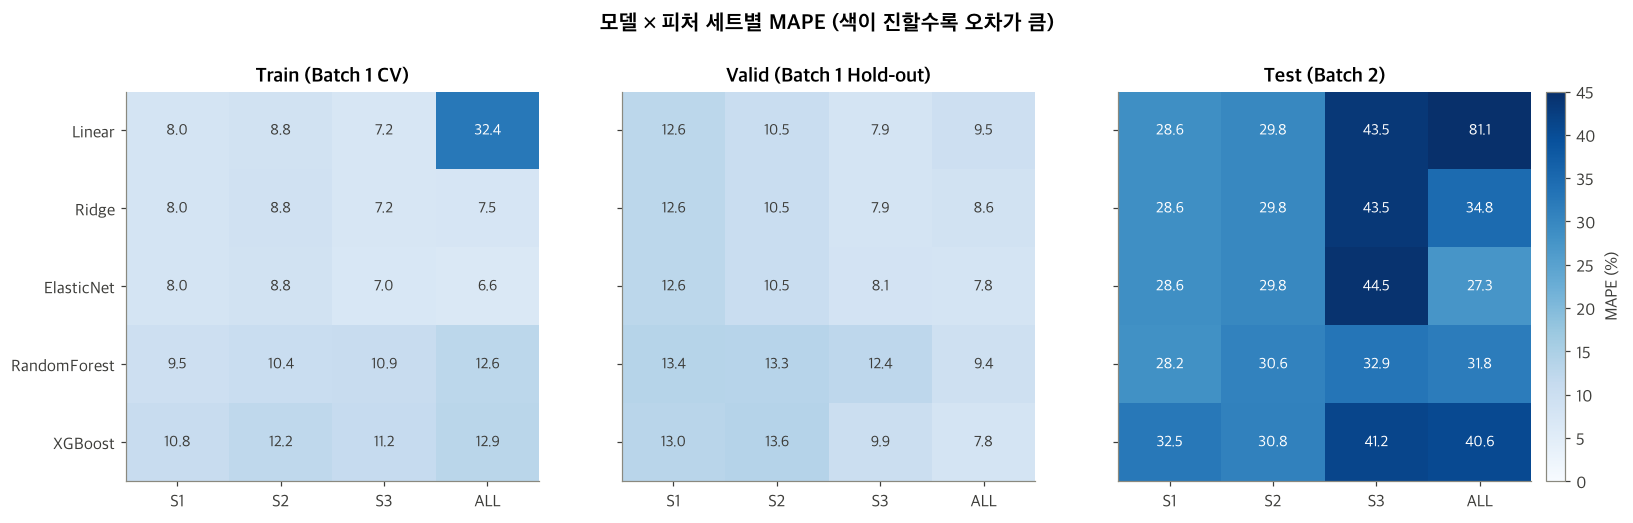

In [5]:
comparison, details = compare_all(b1, b2, valid_policies)
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharey=True)
for ax, metric, title in zip(axes, ["train_cv", "valid", "test"],
                             ["Train (Batch 1 CV)", "Valid (Batch 1 Hold-out)", "Test (Batch 2)"]):
    t = comparison.pivot(index="model", columns="feature_set", values=metric).loc[list(MODELS), list(FEATURE_SETS)]
    im = ax.imshow(t.values, cmap="Blues", vmin=0, vmax=45, aspect="auto")
    ax.set_xticks(range(t.shape[1]), [short(c) for c in t.columns])
    ax.set_yticks(range(t.shape[0]), t.index)
    ax.grid(False)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            v = t.iat[i, j]
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=10, color="white" if v > 25 else TEXT)
    ax.set_title(title)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, label="MAPE (%)")
fig.suptitle("모델 × 피처 세트별 MAPE (색이 진할수록 오차가 큼)", fontsize=14, fontweight="bold", y=1.04)
savefig(fig, "fig13_model_comparison")
plt.show()

In [6]:
first = select_by_valid(comparison, list(MODELS), PLAN_SETS)
first_r = details[(first["model"], first["feature_set"])]
print(f"1차 선택 (피처 세트 S1~S3 × 5개 모델 중 Valid 최저) : {first['model']} · {first['feature_set']}")
report_table(first_r).round(2)

1차 선택 (피처 세트 S1~S3 × 5개 모델 중 Valid 최저) : Linear · S3 + qd_2, fade_slope_91_100


,MAPE (%),계산,비고
구분,,,
Train (Batch 1 CV),7.21,,
Valid (Batch 1 Hold-out),7.93,,
Test (Batch 2),43.46,,
Gap (Train-Valid),0.72,Valid − Train,(+) : 과적합 의심
Gap (Valid-Test),35.53,Test − Valid,(+) : 배치간 일반화 저하 의심
Gap (Target-Test),34.36,Test − Target(9.1),Target : 원논문 9.1%


**[1차 결과]**
- Batch 1 안에서는 좋다 : Train CV 7.2%, Valid 7.9% 로 Target 9.1% 보다 낮다
- 하지만 **Test(Batch 2) 는 43.5%** 로, Valid 대비 35%p 이상 나빠졌다 → Gap(Valid-Test) 가 매우 크다
- Valid 상위 조합들이 대부분 Test 에서 크게 나빠진다 (아래 표) → Batch 1 안의 검증만으로는 배치가 바뀌었을 때의 성능을 판단하기 어려운 것 같다

In [7]:
print("Valid 기준 상위 6개 조합 (참고용으로 Test 함께 표시)")
comparison.sort_values("valid").head(6)[["model", "feature_set", "train_cv", "valid", "test"]]

Valid 기준 상위 6개 조합 (참고용으로 Test 함께 표시)


,model,feature_set,train_cv,valid,test
17,ElasticNet,ALL 후보 20개 (비교용),6.63,7.81,27.27
19,XGBoost,ALL 후보 20개 (비교용),12.92,7.81,40.56
10,Linear,"S3 + qd_2, fade_slope_91_100",7.21,7.93,43.46
11,Ridge,"S3 + qd_2, fade_slope_91_100",7.22,7.94,43.49
12,ElasticNet,"S3 + qd_2, fade_slope_91_100",6.97,8.14,44.46
16,Ridge,ALL 후보 20개 (비교용),7.51,8.64,34.79


---
## 3. 1차 결과 원인 분석

Test 점수로 모델을 바꾸지 않기 위해, **Batch 2 의 정답(수명) 없이 확인할 수 있는 근거**와 EDA(`01_EDA.ipynb`) 결과를 중심으로 원인을 찾는다.

### 3-1. Batch 2 피처 분포가 학습 데이터에서 얼마나 벗어났나

In [8]:
shift_cols = ["dq_var", "dq_lowv_mean", "qd_2", "fade_slope_91_100", "t80_policy", "chargetime_2_6"]
shift = covariate_shift(b1, b2, shift_cols)
shift["EDA : 세 배치 상관 부호"] = ["일관", "일관", "불일치", "일관 (약함)", "불일치", "불일치"]
shift.round(2)

,Batch 1 범위 밖 비율 (%),평균 차이 (Batch 1 표준편차 단위),EDA : 세 배치 상관 부호
feature,,,
dq_var,43.59,0.84,일관
dq_lowv_mean,25.64,0.89,일관
qd_2,53.85,1.88,불일치
fade_slope_91_100,79.49,0.65,일관 (약함)
t80_policy,0.00,-0.76,불일치
chargetime_2_6,0.00,-0.73,불일치


In [9]:
coef = pd.Series(first_r["model"][-1].coef_, index=FEATURE_SETS[first["feature_set"]], name="표준화 계수")
print(f"1차 모델({first['model']} · {short(first['feature_set'])}) 의 계수 — 양수면 값이 클수록 수명을 길게 예측")
coef.round(4).to_frame().T

1차 모델(Linear · S3) 의 계수 — 양수면 값이 클수록 수명을 길게 예측


,dq_var,dq_lowv_mean,qd_2,fade_slope_91_100
표준화 계수,-0.09,0.02,0.03,7.00e-04


**[원인 1] `qd_2` 와 `fade_slope_91_100` 은 Batch 2 에서 학습 범위를 크게 벗어난다**
- `qd_2` (초기 용량) 는 Batch 2 평균이 Batch 1 보다 표준편차의 약 1.9배 높고, 54% 가 Batch 1 범위 밖이다. `fade_slope_91_100` 은 79% 가 범위 밖이다
- 1차 모델에서 `qd_2` 의 계수가 양수라, 초기 용량이 높은 Batch 2 셀의 수명을 더 길게 예측하게 된다
- EDA Q5 에서 `qd_2` 는 "배치 간 평균 차이가 만든 허상 상관으로 보인다" 고 판단했던 피처다 → Batch 1 안에서만 유효한 관계를 학습한 것 같다
- 반면 ΔQ 피처(`dq_var`, `dq_lowv_mean`) 도 범위를 벗어나는 셀이 있지만, **세 배치에서 수명과의 관계가 같은 방향으로 유지**되기 때문에 범위 밖으로 연장해도 의미가 있다고 판단했다

### 3-2. 트리 모델은 학습 범위 밖을 예측하지 못한다

In [10]:
tree_rows = []
for m in ["RandomForest", "XGBoost"]:
    for fs in PLAN_SETS:
        r = details[(m, fs)]
        tree_rows.append({"model": m, "feature_set": short(fs), "Batch 2 예측 최솟값": r["test_pred"].min()})
tree_pred = pd.DataFrame(tree_rows).set_index(["model", "feature_set"])
print(f"Batch 1 최소 수명 : {b1['cycle_life'].min():.0f}  /  Batch 2 최소 수명 : {b2['cycle_life'].min():.0f}")
tree_pred.round(0)

Batch 1 최소 수명 : 534  /  Batch 2 최소 수명 : 392


Batch 2 예측 최솟값
model        feature_set                
RandomForest S1                    555.0
             S2                    591.0
             S3                    571.0
XGBoost      S1                    561.0
             S2                    556.0
             S3                    595.0

**[원인 2] 트리 모델의 예측값은 Batch 1 범위 아래로 내려가지 못한다**
- 트리 모델은 학습 데이터 값들의 평균으로 예측하기 때문에, Batch 1 최소 수명(534) 근처보다 짧게 예측할 수 없다
- Batch 2 는 대부분의 셀이 392 ~ 514 라서 이 구간을 구조적으로 맞힐 수 없다 → EDA Q1 에서 예상한 외삽 한계가 확인됐다

### 3-3. 2차 모델링 기준

원인 분석을 바탕으로 후보를 좁힌다. 선택은 이번에도 **Valid MAPE** 로 한다.

| 기준 | 근거 | 결과 |
|---|---|---|
| 배치 간 관계가 일관된 피처만 사용 | 원인 1, EDA Q5 | `qd_2`, `fade_slope_91_100` 제외 → **S1, S2** |
| 학습 범위 밖 예측이 가능한 모델만 사용 | 원인 2, EDA Q1 | 트리 모델 제외 → **Linear, Ridge, ElasticNet** |
| ALL (비교용) 세트 제외 | EDA Q4 에서 제외한 충전 정책 변수 포함 | 참고 비교로만 사용 |

---
## 4. 2차 모델링 및 최종 성능

In [11]:
cand = comparison[comparison["model"].isin(LINEAR_MODELS) & comparison["feature_set"].isin(ROBUST_SETS)]
print("2차 후보 (S1, S2 × 선형 계열 모델)")
cand[["model", "feature_set", "train_cv", "valid", "params"]].sort_values("valid")

2차 후보 (S1, S2 × 선형 계열 모델)


,model,feature_set,train_cv,valid,params
5,Linear,S2 + dq_lowv_mean,8.79,10.48,{}
7,ElasticNet,S2 + dq_lowv_mean,8.79,10.49,"{'alpha': 0.0001, 'l1_ratio': 0.1}"
6,Ridge,S2 + dq_lowv_mean,8.79,10.50,{'alpha': 0.01}
1,Ridge,S1 dq_var,8.00,12.64,{'alpha': 0.01}
2,ElasticNet,S1 dq_var,8.00,12.64,"{'alpha': 0.0001, 'l1_ratio': 0.1}"
0,Linear,S1 dq_var,8.00,12.64,{}


In [12]:
final = select_by_valid(comparison, LINEAR_MODELS, ROBUST_SETS)
final_r = details[(final["model"], final["feature_set"])]
print(f"최종 모델 : {final['model']} · {final['feature_set']}  |  하이퍼파라미터 : {final_r['params']}")

performance = report_table(final_r)
performance.to_csv(RESULTS_DIR / "model_performance.csv")
performance.round(2)

최종 모델 : Linear · S2 + dq_lowv_mean  |  하이퍼파라미터 : {}


,MAPE (%),계산,비고
구분,,,
Train (Batch 1 CV),8.79,,
Valid (Batch 1 Hold-out),10.48,,
Test (Batch 2),29.76,,
Gap (Train-Valid),1.70,Valid − Train,(+) : 과적합 의심
Gap (Valid-Test),19.28,Test − Valid,(+) : 배치간 일반화 저하 의심
Gap (Target-Test),20.66,Test − Target(9.1),Target : 원논문 9.1%


In [13]:
ref = comparison[(comparison["model"] == "ElasticNet") & (comparison["feature_set"] == "ALL 후보 20개 (비교용)")].iloc[0]
ref_r = details[(ref["model"], ref["feature_set"])]

side = pd.concat({
    f"1차 : {first['model']} · {short(first['feature_set'])}": report_table(first_r)["MAPE (%)"],
    f"최종 : {final['model']} · {short(final['feature_set'])}": report_table(final_r)["MAPE (%)"],
    f"참고 : ElasticNet · ALL": report_table(ref_r)["MAPE (%)"],
}, axis=1)
side.round(2)

,1차 : Linear · S3,최종 : Linear · S2,참고 : ElasticNet · ALL
구분,,,
Train (Batch 1 CV),7.21,8.79,6.63
Valid (Batch 1 Hold-out),7.93,10.48,7.81
Test (Batch 2),43.46,29.76,27.27
Gap (Train-Valid),0.72,1.70,1.18
Gap (Valid-Test),35.53,19.28,19.46
Gap (Target-Test),34.36,20.66,18.17


### Gap 해석
각 Gap 의 원인을 확인하기 위한 값들이다.

In [14]:
valid_err = (final_r["valid_pred"] - valid["cycle_life"]) / valid["cycle_life"] * 100


def policy_spread(d):
    """셀이 2개 이상인 정책의 '같은 정책 안 수명 차이' 평균 (%)"""
    g = d.groupby("policy")["cycle_life"]
    spread = g.agg(lambda x: (x.max() - x.min()) / x.mean() * 100)
    return spread[g.size() >= 2].mean()


y2, p2 = b2["cycle_life"], final_r["test_pred"]
logres2 = np.log10(p2) - np.log10(y2)
evidence = pd.Series({
    "[Train-Valid] 같은 정책 안 수명 차이 : 학습 정책 (%)": policy_spread(train),
    "[Train-Valid] 같은 정책 안 수명 차이 : Hold-out 정책 (%)": policy_spread(valid),
    "[Train-Valid] 오차가 가장 큰 1셀을 뺀 Valid MAPE (%)": valid_err.abs().drop(valid_err.abs().idxmax()).mean(),
    "[Valid-Test] Batch 1 최소 수명보다 짧은 Batch 2 셀 비율 (%)": (y2 < b1["cycle_life"].min()).mean() * 100,
    "[Valid-Test] Batch 2 배치 offset (예측 / 실제, 배)": 10 ** logres2.mean(),
    "[Valid-Test] offset 을 뺀 Test MAPE (%, 진단)": mape(y2, p2 / 10 ** logres2.mean()),
    "[Valid-Test] Batch 2 수명 순서 상관 (Spearman)": spearmanr(p2, y2).correlation,
})
evidence.round(2).to_frame("값")

,값
[Train-Valid] 같은 정책 안 수명 차이 : 학습 정책 (%),6.56
[Train-Valid] 같은 정책 안 수명 차이 : Hold-out 정책 (%),19.04
[Train-Valid] 오차가 가장 큰 1셀을 뺀 Valid MAPE (%),9.16
[Valid-Test] Batch 1 최소 수명보다 짧은 Batch 2 셀 비율 (%),76.92
"[Valid-Test] Batch 2 배치 offset (예측 / 실제, 배)",1.29
"[Valid-Test] offset 을 뺀 Test MAPE (%, 진단)",9.43
[Valid-Test] Batch 2 수명 순서 상관 (Spearman),0.74


| Gap | 값 | 의미 | 왜 이렇게 나왔나 (근거) |
|---|---|---|---|
| Train-Valid | +1.70 | Batch 1 안에서의 과적합은 크지 않음 | 피처 2개짜리 선형 모델이라 학습 데이터에 과하게 맞출 여지가 작다. 남은 차이는 **Hold-out 구성** 때문으로 보인다 : Hold-out 정책 4개는 같은 정책 안에서도 수명 차이가 평균 19.0% 로 학습 정책(6.6%)보다 커서 예측이 더 어렵다 (예 : `4.8C(80%)-4.8C` 의 두 셀 636 / 870). 오차가 가장 큰 1셀을 빼면 Valid 는 9.2% |
| Valid-Test | +19.28 | 배치가 바뀌면서 크게 나빠짐 | ① Batch 2 셀의 77% 가 Batch 1 최소 수명보다 짧아 학습 범위 밖을 예측해야 한다 ② Batch 2 전체가 평균 1.29배 길게 예측되는 **배치 offset** 이 있다. offset 만 빼면 Test 는 9.4% 로 Valid(10.5%)보다도 낮다 → **Valid-Test Gap 은 거의 전부 배치 offset 에서 온 것 같다** ③ 셀 간 수명 순서는 유지된다 (Spearman 0.74) |
| Target-Test | +20.66 | 원논문 Target 보다 크게 높음 | Valid-Test 와 같은 원인이 그대로 남은 결과다. 학습과 같은 조건에서의 성능(Valid 10.5%)과 offset 을 뺀 Test(9.4%)는 Target 9.1% 와 비슷한 수준이다 → 모델이 배울 수 있는 관계는 배웠고, **차이는 배치가 바뀌면서 생기는 offset** 이라고 판단했다 |

**[1차 대비 최종 모델]**
- 1차 → 최종 : Test 43.5% → **29.8%** 로 13.7%p 줄었다. 대신 Valid 는 7.9% → 10.5% 로 늘었다 → `qd_2` 가 Batch 1 안에서는 오차를 줄여주지만, 그 관계가 Batch 2 로 이어지지 않았다는 3절의 판단과 맞는다
- 참고로 ElasticNet · ALL (27.3%) 은 최종 모델과 2.5%p 차이로, 피처를 20개로 늘려도 Batch 2 오차는 크게 줄지 않았다 → 남은 오차는 피처 선택보다 배치 자체의 차이에서 오는 것 같다

---
## 5. 예측 vs 실제

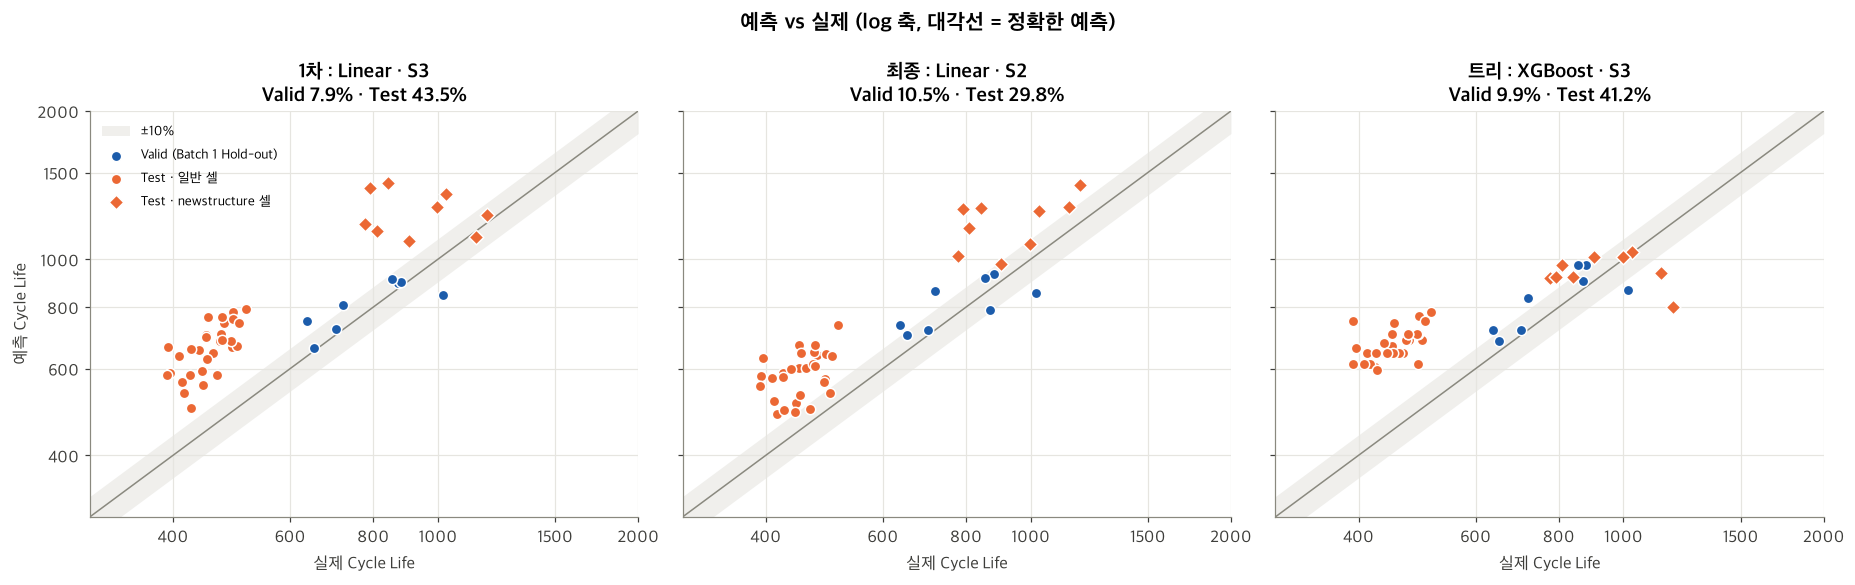

In [15]:
show = [(first["model"], first["feature_set"], f"1차 : {first['model']} · {short(first['feature_set'])}"),
        (final["model"], final["feature_set"], f"최종 : {final['model']} · {short(final['feature_set'])}"),
        ("XGBoost", "S3 + qd_2, fade_slope_91_100", "트리 : XGBoost · S3")]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4), sharex=True, sharey=True)
lims = [300, 2000]
for ax, (m, fs, title) in zip(axes, show):
    r = details[(m, fs)]
    ax.plot(lims, lims, color=MUTED, lw=1)
    ax.fill_between(lims, [l * 0.9 for l in lims], [l * 1.1 for l in lims], color=GRID, alpha=0.6, lw=0, label="±10%")
    ax.scatter(valid["cycle_life"], r["valid_pred"], s=46, color="#1c5cab", edgecolor="white", lw=1,
               label="Valid (Batch 1 Hold-out)", zorder=3)
    for ns, marker, lab in [(False, "o", "Test · 일반 셀"), (True, "D", "Test · newstructure 셀")]:
        mask = b2["newstructure"] == ns
        ax.scatter(b2.loc[mask, "cycle_life"], r["test_pred"][mask], s=46, marker=marker,
                   color=BATCH_COLORS["b2"], edgecolor="white", lw=1, label=lab, zorder=3)
    ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims, xlabel="실제 Cycle Life",
           title=f"{title}\nValid {r['valid']:.1f}% · Test {r['test']:.1f}%")
    ticks = [400, 600, 800, 1000, 1500, 2000]
    ax.set_xticks(ticks, [str(t) for t in ticks])
    ax.set_yticks(ticks, [str(t) for t in ticks])
    ax.minorticks_off()
axes[0].set_ylabel("예측 Cycle Life")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("예측 vs 실제 (log 축, 대각선 = 정확한 예측)", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig14_pred_vs_actual")
plt.show()

---
## 6. 최종 모델 오류 분석

### 6-1. 어떤 셀에서 크게 틀렸나
부호 있는 오차(%) = (예측 − 실제) / 실제 × 100 → (+) 면 수명을 길게 예측

In [16]:
def signed_ape(r):
    return (r["test_pred"] - b2["cycle_life"]) / b2["cycle_life"] * 100


err = pd.DataFrame({title: signed_ape(details[(m, fs)]) for m, fs, title in show})
group = np.where(b2["newstructure"], "newstructure 셀 (9개)", "일반 셀 (30개)")
summary_err = pd.concat({
    "평균 부호 오차 (%)": err.groupby(group).mean(),
    "MAPE (%)": err.abs().groupby(group).mean(),
}, axis=1)
print("Batch 2 셀 그룹별 오차")
summary_err.T.round(1)

Batch 2 셀 그룹별 오차


newstructure 셀 (9개)  일반 셀 (30개)
평균 부호 오차 (%) 1차 : Linear · S3                  35.6        45.6
             최종 : Linear · S2                  28.3        30.2
             트리 : XGBoost · S3                  3.0        49.3
MAPE (%)     1차 : Linear · S3                  36.2        45.6
             최종 : Linear · S2                  28.3        30.2
             트리 : XGBoost · S3                 14.2        49.3

In [17]:
final_err = signed_ape(final_r)
worst = (b2.assign(예측=final_r["test_pred"].round(0), 오차_pct=final_err.round(1))
           .loc[final_err.abs().sort_values(ascending=False).index[:8],
                ["policy", "newstructure", "cycle_life", "예측", "오차_pct"]])
print("최종 모델에서 오차가 가장 큰 셀 8개")
worst

최종 모델에서 오차가 가장 큰 셀 8개


,policy,newstructure,cycle_life,예측,오차_pct
cell_id,,,,,
b2c9,5.6C(26%)-4.5C-newstructure,True,791.0,1267.0,60.2
b2c15,3.6C(9%)-5C,False,396.0,629.0,58.9
b2c44,5.2C(58%)-4C-newstructure,True,841.0,1273.0,51.4
b2c18,5.2C(50%)-4.25C,False,449.0,671.0,49.5
b2c6,3.6C(9%)-5C,False,393.0,580.0,47.5
b2c24,4.8C(80%)-4.8C,False,514.0,737.0,43.4
b2c32,4.8C(80%)-4.8C-newstructure,True,809.0,1158.0,43.2
b2c29,5.2C(58%)-4C,False,452.0,646.0,42.9


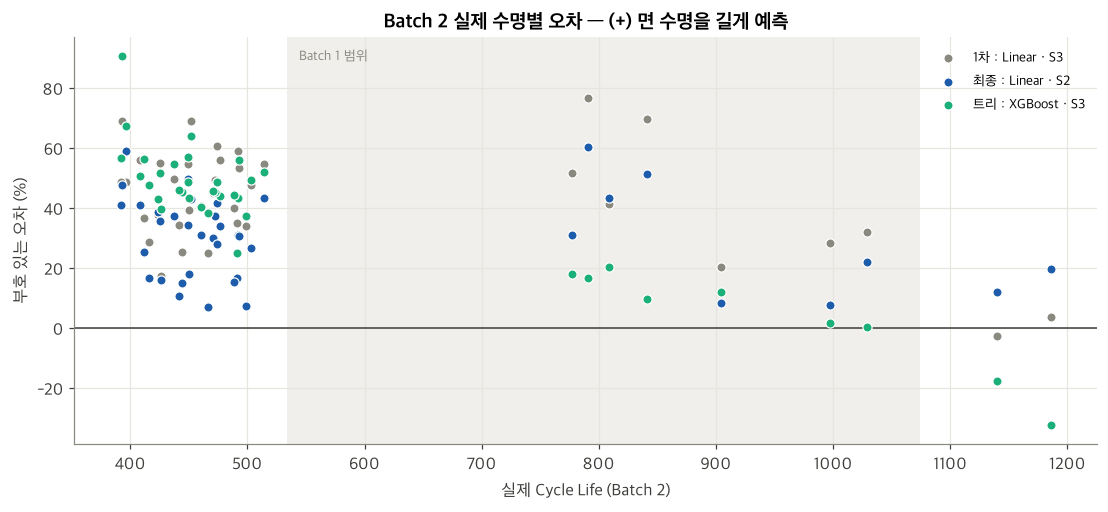

In [18]:
fig, ax = plt.subplots(figsize=(12, 4.8))
for title, color in zip(err.columns, ["#8a897f", "#1c5cab", BATCH_COLORS["b3"]]):
    ax.scatter(b2["cycle_life"], err[title], s=36, color=color, edgecolor="white", lw=0.8, label=title, zorder=3)
ax.axhline(0, color=TEXT, lw=1)
ax.axvspan(b1["cycle_life"].min(), b1["cycle_life"].max(), color=GRID, alpha=0.6, lw=0)
ax.text(b1["cycle_life"].min() + 10, ax.get_ylim()[1] * 0.92, "Batch 1 범위", color=MUTED, fontsize=9)
ax.set(xlabel="실제 Cycle Life (Batch 2)", ylabel="부호 있는 오차 (%)", title="Batch 2 실제 수명별 오차 — (+) 면 수명을 길게 예측")
ax.legend(fontsize=9)
savefig(fig, "fig15_error_analysis")
plt.show()

### 6-2. 오차의 구성 : 순서는 맞히는가, 배치 전체가 밀렸는가

- **Spearman 순위 상관** : Batch 2 안에서 셀 간 수명 순서를 얼마나 맞히는지
- **배치 offset 제거 (진단용)** : log 예측 오차의 평균(배치 전체가 밀린 정도)을 빼고 다시 계산한 MAPE. Batch 2 정답을 모두 쓰므로 **실제 성능이 아니라 오차 구성을 보기 위한 진단값**이다
- **기준 셀 k 개로 보정 (참고)** : Batch 2 셀 k 개만 수명을 안다고 가정하고, 그 셀들로 offset 을 추정해 나머지 셀을 보정. 무작위로 200번 반복한 평균

In [19]:
def decompose(r, ks=(3, 5), n_rep=200, seed=0):
    y, p = b2["cycle_life"], r["test_pred"]
    logres = np.log10(p) - np.log10(y)
    out = {"Test MAPE (%)": r["test"], "Spearman": spearmanr(p, y).correlation,
           "배치 offset (배)": 10 ** logres.mean(),
           "offset 제거 MAPE (%, 진단)": mape(y, p / 10 ** logres.mean())}
    rng = np.random.default_rng(seed)
    for k in ks:
        sc = []
        for _ in range(n_rep):
            idx = rng.choice(len(b2), k, replace=False)
            rest = np.ones(len(b2), bool)
            rest[idx] = False
            sc.append(mape(y[rest], p[rest] / 10 ** logres.iloc[idx].mean()))
        out[f"기준 셀 {k}개 보정 MAPE (%)"] = np.mean(sc)
    return pd.Series(out)


decomp = pd.DataFrame({title: decompose(details[(m, fs)]) for m, fs, title in show})
decomp.round(2)

,1차 : Linear · S3,최종 : Linear · S2,트리 : XGBoost · S3
Test MAPE (%),43.46,29.76,41.20
Spearman,0.85,0.74,0.81
배치 offset (배),1.42,1.29,1.36
"offset 제거 MAPE (%, 진단)",9.59,9.43,13.39
기준 셀 3개 보정 MAPE (%),11.26,10.89,15.66
기준 셀 5개 보정 MAPE (%),10.69,10.30,14.94


**[오류 분석 해석]**
- **오차 방향이 한쪽으로 쏠려 있다** : 최종 모델은 일반 셀(+30.2%), newstructure 셀(+28.3%) 모두 수명을 길게 예측했다. 셀 그룹과 상관없이 비슷한 비율로 밀려 있어서, 배치 전체에 공통된 차이가 있는 것 같다
- **순서는 맞힌다** : Spearman 0.74 → Batch 2 안에서 어떤 셀이 오래 가고 짧은지는 상당히 맞힌다
- **오차의 대부분은 배치 offset 이다** : 예측이 실제보다 평균 1.29배 길다. 이 offset 하나만 빼면 MAPE 가 29.8% → 9.4% 로 원논문 Target(9.1%)과 비슷해진다 (진단값)
- **기준 셀 3~5개로 보정하면 10.9% → 10.3%** : 새 배치에서 셀 몇 개만 실제 수명을 확인하면 offset 을 대부분 잡을 수 있다
- 트리 모델은 offset 을 빼도 13.4% 로 남는다 → 학습 범위 밖을 예측하지 못하는 구조적 한계 때문에 선형 모델보다 불리하다
- 오차가 가장 큰 셀은 newstructure 셀(`b2c9`, `b2c44`)과 Batch 2 일반 셀 중 가장 짧은 셀들(`b2c15`, `b2c6`)이다. Batch 2 안에서 휴지 시간이 약 21분인 일반 셀(+30.2%)과 약 0.3분인 newstructure 셀(+28.3%)이 비슷하게 밀렸다 → offset 은 휴지 시간보다 **Batch 2 배치 전체에 공통된 요인**(셀 생산 로트, 시험 시기 등)에서 온 것 같다. `03_batch3_validation.ipynb` 에서 휴지 시간이 같은 Batch 3 는 offset 이 거의 없는 것(1.06배)으로 다시 확인했다

---
## 7. 최종 모델의 계수

In [20]:
cols = FEATURE_SETS[final["feature_set"]]
est = final_r["model"][-1]
pd.DataFrame({"표준화 계수": est.coef_}, index=cols).round(4).T

,dq_var,dq_lowv_mean
표준화 계수,-0.12,0.05


**[계수 해석]**
- `dq_var` 의 계수가 음수(−0.12) : ΔQ(V) 분산이 클수록 수명이 짧다 → EDA Q3 의 관계와 같은 방향
- `dq_lowv_mean` 의 계수는 양수(+0.05) 로, EDA 에서 본 단독 상관(음수)과 방향이 반대다. 두 피처의 상관이 0.92 로 높아서, `dq_lowv_mean` 은 단독 효과라기보다 `dq_var` 를 보정하는 역할을 하는 것 같다 → 계수 부호만으로 피처의 의미를 해석하지 않는 것이 맞다고 판단했다

---
## 8. 결론 및 한계

**결론**
- EDA 기반 설계 전략으로 만든 1차 모델(Linear · S3)은 Batch 1 안에서는 Valid 7.9% 였지만 Batch 2 에서 43.5% 로 크게 나빠졌다
- Batch 2 정답 없이 확인한 피처 분포와 EDA 를 근거로, 배치 간 관계가 일관된 ΔQ 피처와 선형 모델만 남겨 **최종 모델 Linear · S2 (`dq_var`, `dq_lowv_mean`)** 를 선택했다. Test 29.8%
- 오차의 대부분은 배치 전체가 일정 비율(약 1.29배)로 길게 예측되는 offset 이고, Batch 2 안에서의 수명 순서는 맞힌다 (Spearman 0.74). offset 을 빼면 9.4%, 기준 셀 3~5개로 보정하면 약 10~11%

**한계**
- 2차 수정 근거는 Batch 2 정답 없이 확인한 피처 분포와 EDA 를 중심으로 했지만, 1차 Test 의 오차 패턴도 참고했다. 따라서 최종 모델의 Test 29.8% 는 완전히 독립된 평가라고 보기 어렵다
- Valid 는 Hold-out 8셀이라 셀 한두 개에 따라 결과가 흔들릴 수 있다
- offset 의 원인이 Batch 2 배치 전체에 공통된 요인으로 보이지만, 셀 생산 로트 · 시험 시기 같은 정보가 데이터에 없어 직접 확인하지 못했다
- 기준 셀 보정 결과는 Batch 2 정답 일부를 사용한 참고값이며, 실제 운영에서는 기준 셀을 수명 끝까지 시험하는 시간이 필요하다